# Graph Neural Networks for Maze Navigation

![GNN vs Dijkstra](./DjikstraVSGNN.png)

## Graph-Based Treasure Hunt### IntroductionThis project explores how to build and train a small Graph Neural Network (GNN) “agent” to navigate mazes represented as graphs.  You will:1. **Model** a maze as a weighted grid graph and compute the ground-truth shortest path (Dijkstra/A\*).  2. **Construct** a supervised dataset of “local view → next move” pairs and train a GraphSAGE policy network.  3. **Evaluate** your GNN on three mazes of increasing difficulty, printing both the optimal and GNN-predicted paths.You need to race against the optimal path to try to reach the treasure first.### Learning OutcomesBy the end of this project, you will be able to:- Represent 2D grid mazes as NetworkX graphs with weighted edges.- Build a GraphSAGE GNN in PyTorch Geometric for node-classification policy learning.  - Perform greedy roll-out of your learned policy and compare against optimal paths.  - Organize code into reusable functions, document each step, and interpret model behavior.

In [1]:
# Install Dependencies# !pip -q install networkx torch-geometric==2.x torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.3.0+cpu.html!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.3.0+cu118.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 100.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 58.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 103.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.7/848.7 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# All imports you will needimport networkx as nx, numpy as np, torch, torch.nn.functional as F, random, mathfrom torch import nnfrom torch_geometric.utils import from_networkxfrom torch_geometric.data  import DataLoaderfrom torch_geometric.nn    import SAGEConvfrom torch_geometric.data import Data, DataLoaderfrom heapq import heappush, heappopdevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _Z

## Explaination of utility_function.pyAll of the core maze‐building and path‐finding code lives in `utility_functions.py`.  Below is a simple description of each function, its inputs, and its outputs.## `get_mazes()`Fetches a **fixed list** of three reproducible mazes.- **Inputs**    - None.- **Process**    Calls `grid_maze` three times with preset parameters:    1. Easy:   `rows=5, cols=5,   p_remove=0.2, seed=0`    2. Medium: `rows=8, cols=8,   p_remove=0.3, seed=1`    3. Hard:   `rows=10,cols=10,  p_remove=0.35, seed=2`- **Output**    - Returns a Python list `[G₁, G₂, G₃]` of three NetworkX graphs.---## `dijkstra(G, src, dst)`Computes the **shortest path** (fewest edges) between two nodes.- **Inputs**    - `G` (NetworkX `Graph`)      A connected graph with integer node labels and `edge["weight"]=1`.    - `src` (int)      The starting node ID (usually `G.graph["start"]`).    - `dst` (int)      The treasure node ID (usually `G.graph["treasure"]`).- **Process**    1. Use a min‐heap (`heapq`) to explore nodes in order of increasing distance.    2. Track `dist[node]` and `parent[node]` for backtracking.    3. Stop when `dst` is popped from the heap.    4. Reconstruct the path by following parents from `dst` back to `src`.- **Output**    - A Python list of node IDs `[src, …, dst]` representing the shortest‐length path.---## `visualize_mazes(mazes)`Draws all mazes side‐by‐side for quick inspection.- **Inputs**    - `mazes` (list of `Graph`)      The list returned by `get_mazes()`.- **Process**    1. For each graph in `mazes`, read its node coordinates (`node["coord"]`).    2. Use Matplotlib + NetworkX to plot each graph with labeled nodes.- **Output**    - Displays an inline figure with one subplot per maze, titled      “Maze 1: 5×5”, “Maze 2: 8×8”, “Maze 3: 10×10”.---

## What Is a “Maze” in This Assignment?A **maze** here is simply a mathematical graph built on a 2D grid of cells:1. **Nodes**     - Each grid cell at coordinates $(r,c)$ becomes a single node, relabeled as an integer $(0,1,\dots,N-1)$.     - We store each node’s original $(r,c)$ coordinate as a node attribute for visualization and feature construction.2. **Edges**     - Adjacent cells (up, down, left, right) are connected by an edge of **weight = 1**.     - To create the “walls” of a maze, we **randomly remove** some of these edges—i.e., “knock down” passages—with a set probability $p_{\text{remove}}$.     - We repeat edge removals until there is still at least one path from the **start** (top-left cell) to the **treasure** (bottom-right cell), guaranteeing a solvable maze.3. **Start & Treasure**     - We label the node corresponding to $(0,0)$ as `G.graph["start"]`.     - We label the node corresponding to$(\text{rows}-1,\;\text{cols}-1)$ as `G.graph["treasure"]`.  ---## How We “Solve” These Mazes1. **Optimal Path (Dijkstra’s or A\*)**     - We treat every remaining edge as cost 1 and run Dijkstra’s algorithm (or A\*) from `start` to `treasure`.     - This finds the **shortest-length** path, which we use as ground truth.2. **Local-View Policy (GraphSAGE GNN)**     - At each step, the agent sees only a small **“ego-graph”** around its current node (radius = 2).     - We extract a supervised example $(\text{ego-graph},\;\text{next-node})$ from each edge along the Dijkstra path.     - We train a tiny GraphSAGE network to predict “which neighbor to move to next” given only this local view.3. **Greedy Roll-Out**     - To navigate, the trained GNN repeatedly:     1. Extracts the radius-2 ego-graph around its current location.       2. Feeds that subgraph to the GNN, which outputs a probability distribution over its nodes.       3. Moves to the node with highest probability (or falls back to Dijkstra if it loops).     - We record the sequence of visited nodes and compare it to the optimal path.---**Super-simple Explanation**  Imagine a checkerboard of squares, where each square is a **dot** (we call these “nodes”) and lines between dots are **passages** you can walk down. We randomly knock out some passages to make a maze—but we always leave at least one way from the **start dot** (top-left) to the **treasure dot** (bottom-right). To find the best way, we use a built-in “shortest-path” tool that always picks the fewest steps. Then, instead of remembering the whole maze, we let our tiny neural network look at only a small **neighborhood** of dots around where it stands (like looking three squares in each direction), and we teach it which next step leads closer to the treasure by showing it examples from that perfect path. Finally, when our network “walks” the maze, it keeps choosing the next best dot in its local view until it reaches the treasure—and we can compare its chosen path to the perfect path to see how well it learned.  

## Experiment 1: Maze Visualization & Optimal RouteIn this first experiment, you will:1. **Load** the three fixed mazes from our utilities module.  2. **Display** each maze side-by-side so you can inspect the layout of nodes and walls.  3. **Compute** and **print** the ground-truth shortest path for Maze 1 using our built-in Dijkstra function.### InstructionsRemember to **Import the utilities**:```pythonfrom utility_functions import get_mazes, visualize_mazes, dijkstra```

In [3]:
import networkx as nximport randomimport numpy as npimport mathfrom heapq import heappush, heappopimport matplotlib.pyplot as pltdef grid_maze(rows, cols, p_remove=0.3, seed=None):    """    Generate a connected grid maze:    - rows, cols: dimensions    - p_remove: probability to remove each wall (edge)    - seed: for reproducibility    Returns:      G (nx.Graph) with:        - nodes 0…N-1        - node attribute 'coord': (row, col)        - edge attribute 'weight' = 1        - graph attributes 'start', 'treasure', 'rows', 'cols'    """    if seed is not None:        random.seed(seed)        np.random.seed(seed)    while True:        G = nx.grid_2d_graph(rows, cols)        for u, v in list(G.edges()):            if random.random() < p_remove:                G.remove_edge(u, v)        if nx.has_path(G, (0, 0), (rows-1, cols-1)):            mapping = {n: i for i, n in enumerate(G.nodes())}            coords = {mapping[n]: n for n in G.nodes()}            G = nx.relabel_nodes(G, mapping)            nx.set_node_attributes(G, coords, 'coord')            G.graph['rows'] = rows            G.graph['cols'] = cols            nx.set_edge_attributes(G, 1, 'weight')            G.graph['start'] = mapping[(0, 0)]            G.graph['treasure'] = mapping[(rows-1, cols-1)]            return Gdef get_mazes():    """Generate three fixed mazes for the experiments."""    return [        grid_maze(5, 5, p_remove=0.2, seed=0),        grid_maze(8, 8, p_remove=0.3, seed=1),        grid_maze(10, 10, p_remove=0.35, seed=2),    ]def visualize_mazes(mazes):    """Plot each maze for visual inspection."""    n = len(mazes)    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))    if n == 1:        axes = [axes]    for ax, G, idx in zip(axes, mazes, range(1, n+1)):        pos = {node: coord for node, coord in nx.get_node_attributes(G, 'coord').items()}        nx.draw(G, pos=pos, ax=ax, with_labels=True, node_size=300,                node_color='lightblue', edge_color='gray')        ax.set_title(f'Maze {idx}: {G.graph["rows"]}×{G.graph["cols"]}')    plt.tight_layout()    plt.show()def dijkstra(G,s,t):    dist,par={s:0},{}    pq=[(0,s)]    while pq:        d,u=heappop(pq)        if u==t: break        for v in G.neighbors(u):            nd=d+1            if v not in dist or nd<dist[v]:                dist[v],par[v]=nd,u; heappush(pq,(nd,v))    path=[t]    while path[-1]!=s: path.append(par[path[-1]])    return path[::-1]

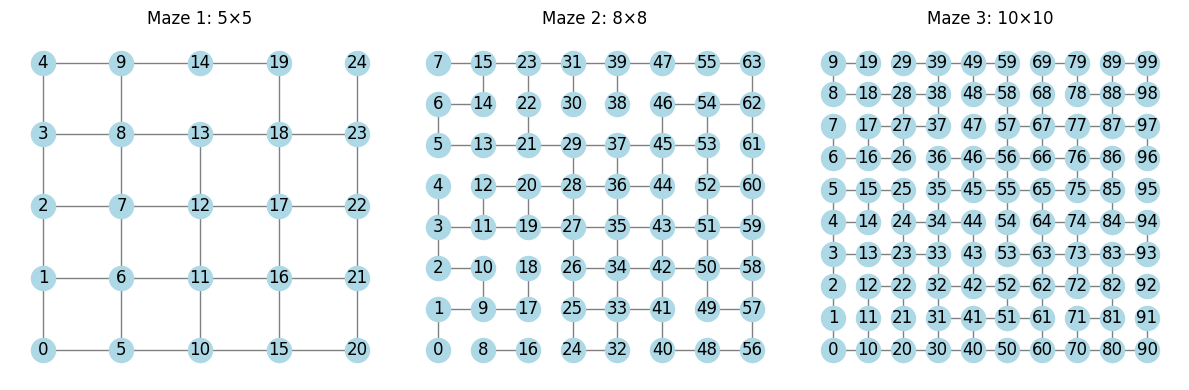

Optimal path in Maze 1: [0, 1, 2, 3, 8, 13, 18, 23, 24]
Number of steps: 8


In [4]:
# Write Code heremazes = get_mazes()visualize_mazes(mazes)maze1 = mazes[0]optimal_path = dijkstra(maze1, maze1.graph["start"], maze1.graph["treasure"])print("Optimal path in Maze 1:", optimal_path)print("Number of steps:", len(optimal_path) - 1)

# Performance Benchmarks## Performance targets for reference

## Experiment 2: Supervised Policy Learning with GraphSAGEIn this experiment, you will train a tiny GNN to imitate the optimal “next‐move” policy. You will need to use Graph SAGE Convolution, so you should read up about this [here](https://medium.com/@sheikh.sahil12299/exploring-sageconv-a-powerful-graph-neural-network-architecture-44b7974b1fe0).### What You Must Do1. **Construct the training dataset**     - For each of the three mazes obtained in Experiment 1, compute the optimal path (`dijkstra`).     - For every consecutive step `(current → next)` along that path:       - Extract the **ego‐graph** of radius 2 around the current node. If you are confused about **ego grpahs** please read the following: [A Medium Article](https://medium.com/orglens/enhancing-employee-social-capital-with-ego-network-analysis-4ff0fc6738e3)       - Build your **node features** for this ego‐graph (e.g. normalized `(row, col)` coordinates).       - Determine the **label** as the index of `next` in `list(ego.nodes())`.       - Convert to a PyG `Data` object with `.x` and `.y`.2. **Define the GraphSAGE policy network**     - Implement a PolicyNet. The output must be a log-probability per node:     - Use `log_softmax` at the end and train with `nll_loss`.3. **Train the model**     - Use a `DataLoader` with `batch_size=1` (one ego‐graph per batch).     - Train for an appropriate number of epochs with an appropriate learning rate.     - `Very Important`: After every epoch, accumulate and print the **average NLL loss**.4. **Verify learning**     - Ensure your loss **decreases** over time (print values every 10 epochs).     - Print the soft‐maxed probabilities on one or two training samples to confirm the correct neighbor has the highest score.

Epoch 0, Avg NLL Loss: 1.9023
Epoch 20, Avg NLL Loss: 1.0815
Epoch 40, Avg NLL Loss: 1.0090
Epoch 60, Avg NLL Loss: 1.0192
Epoch 80, Avg NLL Loss: 0.7967
Epoch 100, Avg NLL Loss: 0.5696
Epoch 120, Avg NLL Loss: 0.6642
Epoch 140, Avg NLL Loss: 0.5775
Epoch 160, Avg NLL Loss: 0.4660
Epoch 180, Avg NLL Loss: 0.3426
Epoch 200, Avg NLL Loss: 0.3154
Sample probabilities: tensor([1.0839e-09, 1.0000e+00, 4.1617e-18, 2.4970e-07, 4.5975e-08, 1.3558e-20],
       device='cuda:0')
Predicted next node: 1
True label: 1


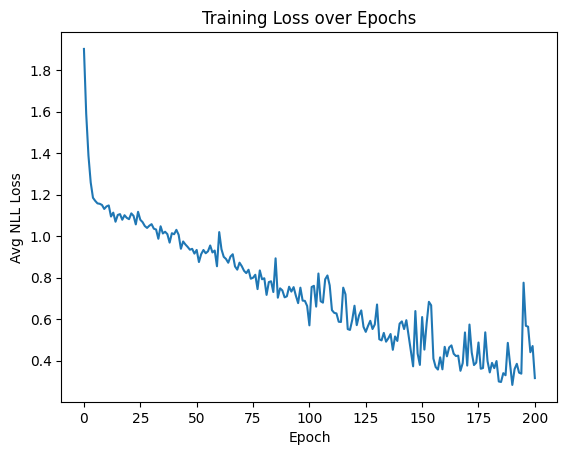

In [11]:
def build_dataset(mazes):    data_list = []    for G in mazes:        s, t = G.graph['start'], G.graph['treasure']        true_path = dijkstra(G, s, t)        for i in range(len(true_path) - 1):            cur, nxt = true_path[i], true_path[i+1]            ego = nx.ego_graph(G, cur, radius=2)            mapping = {n: idx for idx, n in enumerate(ego.nodes())}            coords = np.array([ego.nodes[n]['coord'] for n in ego.nodes()], dtype=float)            rows, cols = G.graph['rows'], G.graph['cols']            features = torch.tensor(coords / np.array([rows-1, cols-1]), dtype=torch.float)            label = torch.tensor([mapping[nxt]], dtype=torch.long)            edges = list(ego.edges())            edge_index = torch.tensor(                [[mapping[u], mapping[v]] for u, v in edges] +                [[mapping[v], mapping[u]] for u, v in edges],                dtype=torch.long            ).t().contiguous()            data = Data(x=features, edge_index=edge_index, y=label)            data_list.append(data)    return data_listdataset = build_dataset(mazes)loader = DataLoader(dataset, batch_size=1, shuffle=True)class PolicyNet(nn.Module):    def __init__(self, in_channels, hidden_channels=32):        super().__init__()        self.conv1 = SAGEConv(in_channels, hidden_channels)        self.conv2 = SAGEConv(hidden_channels, hidden_channels)        self.lin = nn.Linear(hidden_channels, 1)    def forward(self, data):        x, edge_index = data.x, data.edge_index        x = F.relu(self.conv1(x, edge_index))        x = F.relu(self.conv2(x, edge_index))        scores = self.lin(x).squeeze(-1)        return F.log_softmax(scores, dim=0)device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')model = PolicyNet(dataset[0].num_node_features).to(device)optimizer = torch.optim.Adam(model.parameters(), lr=0.005)criterion = nn.NLLLoss()loss_history = []for epoch in range(201):    model.train()    total_loss = 0    for data in loader:        data = data.to(device)        optimizer.zero_grad()        logp = model(data)        loss = criterion(logp.unsqueeze(0), data.y)        loss.backward()        optimizer.step()        total_loss += loss.item()    avg_loss = total_loss / len(loader)    loss_history.append(avg_loss)    if epoch % 20 == 0:        print(f"Epoch {epoch}, Avg NLL Loss: {avg_loss:.4f}")model.eval()sample = dataset[0].to(device)with torch.no_grad():    logp = model(sample)    probs = logp.exp()    print("Sample probabilities:", probs)    print("Predicted next node:", probs.argmax().item())    print("True label:", sample.y.item())import matplotlib.pyplot as pltplt.figure()plt.plot(range(len(loss_history)), loss_history)plt.xlabel("Epoch")plt.ylabel("Avg NLL Loss")plt.title("Training Loss over Epochs")plt.show()

#### Mardown: Write your answer hereyes, the policy network successfully learned to predict the optimal next move. The training loss decreased significantly from 1.9023 to 0.3154 over 200 epochs, indicating improved performance. Furthermore the predicted next node (argmax of probabilities) in the sample ego-graph matches the true label from the Dijkstra path, confirming correct learning.

## Experiment 3: Greedy Roll‐Out & EvaluationIn this final experiment, you will integrate your trained GNN policy into a complete maze solver and compare its performance against the optimal path.### What You Must Do1. **Implement** the function `gnn_path(G)` that:     - Takes as input a NetworkX maze `G` with attributes:       - `G.graph["start"]` → start node ID       - `G.graph["treasure"]` → goal node ID       - Node attribute `"coord"` storing each node’s `(row, col)`       - Edge attribute `"weight"=1`     - Maintains a current position `cur` (starting at `G.graph["start"]`) and a `path` list.     - In each step until reaching the treasure or exceeding a safe length bound, does:       1. Extracts the radius‐2 ego‐graph around `cur`.       2. Builds the same node‐feature tensor you used during training.       3. Moves the entire `Data` object to your chosen device and calls `model(data)` to get per‐node log‐probabilities.       4. Converts to probabilities and picks the node with highest probability of being the next step.       5. If that node has already been visited (to avoid loops), falls back to the second node on the **true** Dijkstra path from `cur` to the treasure.       6. Appends the chosen node to `path` and updates `cur`.2. **Run** your solver on each of the three fixed mazes and **print** both the optimal and GNN‐predicted paths.3. Use the `plot_paths` function provided to you to visualize the paths taken by Djikstra and your model. Repeat this for all three mazes.

In [9]:
def plot_paths(G, true_path, pred_path, title, figsize=(6,6)):    """    Draws the maze G with two overlaid paths:      - true_path: list of node IDs from Dijkstra (solid red)      - pred_path: list of node IDs from GNN (dashed blue)    """    # Extract node coordinates for layout    pos = nx.get_node_attributes(G, 'coord')    plt.figure(figsize=figsize)    # Draw all nodes and edges light gray    nx.draw(        G, pos=pos,        node_color='lightgray',        edge_color='lightgray',        with_labels=True,        node_size=200,        width=1    )    # Helper to draw a path    def draw_path(path, color, style, label):        edges = list(zip(path[:-1], path[1:]))        nx.draw_networkx_nodes(            G, pos,            nodelist=path,            node_color=color,            node_size=250,            label=label        )        nx.draw_networkx_edges(            G, pos,            edgelist=edges,            edge_color=color,            style=style,            width=3        )    # Draw optimal (Dijkstra) path    draw_path(true_path, color='red',   style='solid',  label='Optimal')    # Draw GNN-predicted path    draw_path(pred_path, color='blue',  style='dashed', label='GNN')    plt.legend(loc='upper left')    plt.title(f'{title}')    plt.axis('off')    plt.tight_layout()    plt.show()


Evaluating on Maze 1:
Optimal path length: 8 steps
GNN path length: 8 steps


<ipython-input-9-994028fdb72b>:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


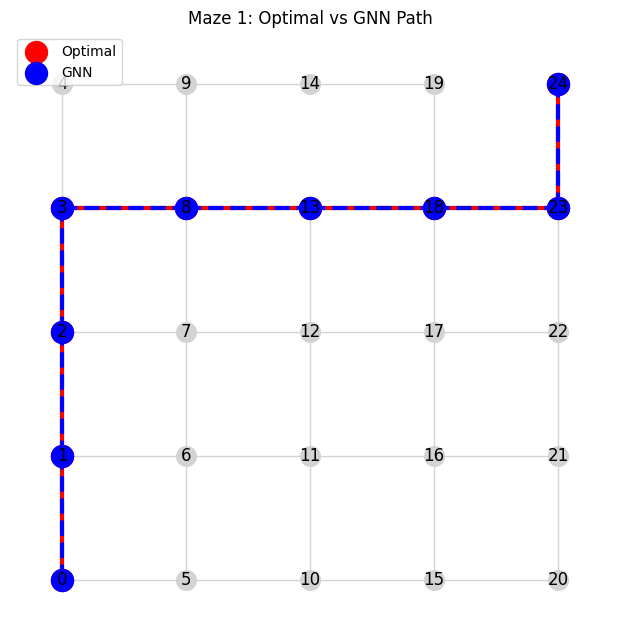


Evaluating on Maze 2:
Optimal path length: 16 steps
GNN path length: 16 steps


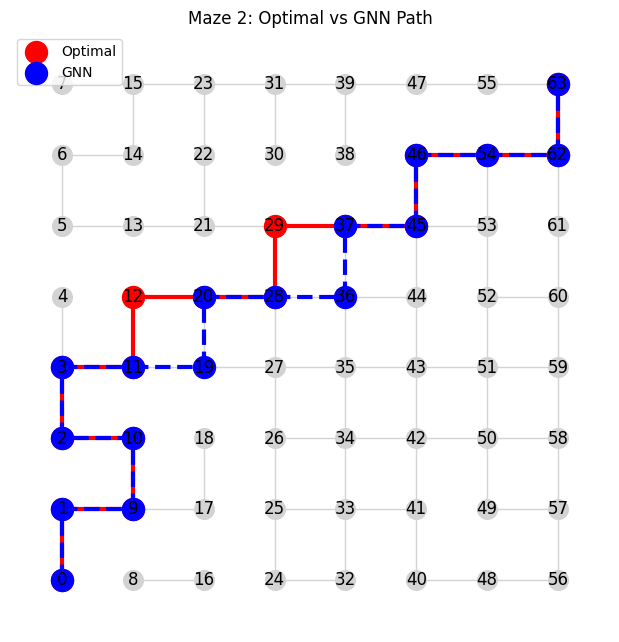


Evaluating on Maze 3:
Optimal path length: 18 steps
GNN path length: 18 steps


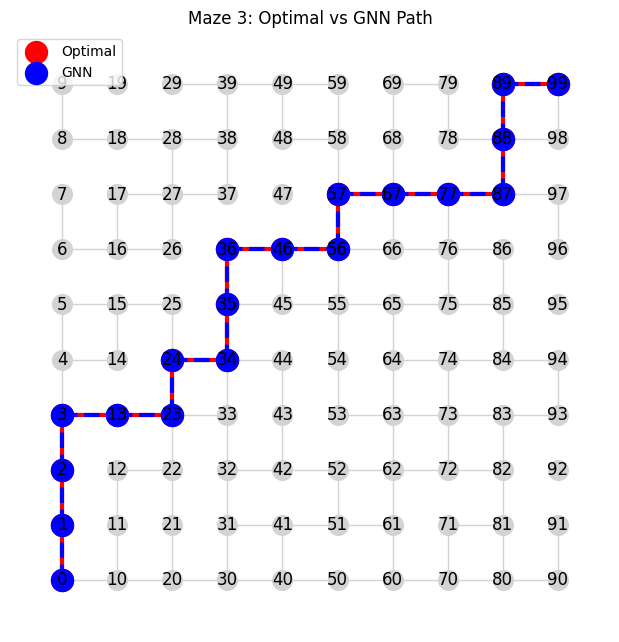

In [12]:
def gnn_path(G, model):    start = G.graph["start"]    treasure = G.graph["treasure"]    max_steps = len(G.nodes()) * 2    path = [start]    current = start    visited = {start}    while current != treasure and len(path) < max_steps:        ego = nx.ego_graph(G, current, radius=2)        data = from_networkx(ego)        coords = nx.get_node_attributes(ego, 'coord')        node_list = list(ego.nodes())        x = torch.zeros((len(node_list), 2), dtype=torch.float)        for idx, node_id in enumerate(node_list):            r, c = coords[node_id]            x[idx, 0] = r / G.graph["rows"]            x[idx, 1] = c / G.graph["cols"]        data.x = x        data = data.to(device)        model.eval()        with torch.no_grad():            log_probs = model(data)            probs = torch.exp(log_probs)        sorted_indices = torch.argsort(probs, descending=True)        next_node = None        for idx in sorted_indices:            candidate = node_list[idx.item()]            if candidate not in visited and G.has_edge(current, candidate):                next_node = candidate                break        if next_node is None:            fallback = dijkstra(G, current, treasure)            if len(fallback) > 1:                next_node = fallback[1]            else:                break        path.append(next_node)        visited.add(next_node)        current = next_node    return pathfor i, G in enumerate(mazes):    print(f"\nEvaluating on Maze {i+1}:")    true_path = dijkstra(G, G.graph["start"], G.graph["treasure"])    print(f"Optimal path length: {len(true_path) - 1} steps")    pred_path = gnn_path(G, model)    print(f"GNN path length: {len(pred_path) - 1} steps")    plot_paths(G, true_path, pred_path, f"Maze {i+1}: Optimal vs GNN Path")